# Randomisation Checks

**Phase 3.** Does the random assignment actually look random?

This notebook runs *before* any treatment effect has been computed, and it can:
every check below reads **pre-treatment covariates and assignment counts only**.
Nothing here touches `visit`, `conversion` or `spend` split by arm. That ordering
is the point — randomisation is verified while the outcome blind is still fully
intact, so the verdict cannot have been influenced by knowing which arm won.

Logic lives in `src/balance.py`; this notebook is the narrative.

Two questions, in order:

1. **Sample ratio mismatch (SRM)** — did each arm receive the share of traffic it
   was supposed to?
2. **Covariate balance** — do the arms look alike on characteristics measured
   *before* the campaign?

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
from src.balance import (
    arm_counts, srm_test, load_balance,
    standardised_mean_differences, smd_noise_calibration, SMD_THRESHOLD,
)
from src.db import get_engine

pd.set_option("display.max_rows", 60, "display.width", 120)
engine = get_engine()

## 1. Sample ratio mismatch

The design called for an equal three-way split. SRM asks whether the realised
counts are further from that than chance allows.

SRM matters more than it looks. It is the canonical symptom of a broken
experiment — a logging bug, a redirect that drops traffic, a bot filter applied
unevenly. **The correct response to a real SRM is to stop and investigate the
assignment mechanism, not to adjust for the imbalance.** Whatever corrupted the
assignment may equally have corrupted the outcomes, and no covariate adjustment
repairs that.

In [2]:
counts = arm_counts(engine)
srm = srm_test(counts)

print(f"{'arm':<16}{'n':>8}{'vs equal split':>17}")
for arm, n in srm["observed"].items():
    print(f"{arm:<16}{n:>8,}{n - srm['expected_per_arm']:>+17.1f}")

print(f"\nchi2({srm['df']}) = {srm['chi2']:.4f}   p = {srm['p_value']:.4f}")
print(f"SRM detected: {srm['srm_detected']}")

arm                    n   vs equal split
Mens E-Mail       21,307            -26.3
No E-Mail         21,306            -27.3
Womens E-Mail     21,387            +53.7

chi2(2) = 0.2025   p = 0.9037
SRM detected: False


**No SRM.** p = 0.90 — the arm sizes are almost exactly what an equal split
predicts, with the largest deviation being 54 customers out of ~21,300 (0.25%).

Worth noting what this does *not* prove. Passing SRM means assignment counts are
fine; it says nothing about whether the arms are similar in composition. That is
the next check.

## 2. Covariate balance ("Table 1")

For every pre-treatment covariate, compare each treatment arm against control
using the **standardised mean difference**:

$$\text{SMD} = \frac{\bar{x}_t - \bar{x}_c}{\sqrt{(s^2_t + s^2_c)/2}}$$

Dividing by the pooled SD makes the statistic unit-free, which is the whole
point: it puts `history` (dollars) and `newbie` (a proportion) on one axis so a
single table and a single plot can hold both.

The eight covariates fixed in `PRE_REGISTRATION.md` §5 expand to 18 rows, because
multi-level categoricals get one row per level. Two contrasts gives 36
comparisons.

In [3]:
smd = standardised_mean_differences(load_balance(engine))

table = smd[["covariate", "level", "contrast", "mean_treatment", "mean_control", "smd"]]
table.style.format({
    "mean_treatment": "{:.4f}", "mean_control": "{:.4f}", "smd": "{:+.4f}",
}).hide(axis="index")

covariate,level,contrast,mean_treatment,mean_control,smd
channel,Multichannel,Mens E-Mail vs Control,0.1209,0.1223,-0.0042
channel,Multichannel,Womens E-Mail vs Control,0.1206,0.1223,-0.0053
channel,Phone,Mens E-Mail vs Control,0.4337,0.4378,-0.0083
channel,Phone,Womens E-Mail vs Control,0.4420,0.4378,+0.0086
channel,Web,Mens E-Mail vs Control,0.4454,0.4399,+0.0110
channel,Web,Womens E-Mail vs Control,0.4374,0.4399,-0.0051
history,dollars,Mens E-Mail vs Control,242.8359,240.8827,+0.0076
history,dollars,Womens E-Mail vs Control,242.5366,240.8827,+0.0065
history_segment,1) $0 - $100,Mens E-Mail vs Control,0.3625,0.3573,+0.0109
history_segment,1) $0 - $100,Womens E-Mail vs Control,0.3569,0.3573,-0.0007


In [4]:
n_comparisons = len(smd)
n_flagged = int(smd.flagged.sum())
n_nominal_sig = int((smd.nominal_p < 0.05).sum())
worst = smd.loc[smd.abs_smd.idxmax()]

print(f"comparisons            {n_comparisons}")
print(f"|SMD| > {SMD_THRESHOLD}           {n_flagged}")
print(f"largest |SMD|          {worst.abs_smd:.4f}  ({worst.covariate} / {worst.level})")
print(f"nominal p < 0.05       {n_nominal_sig}   (chance alone would give ~{0.05 * n_comparisons:.1f})")

comparisons            36
|SMD| > 0.1           0
largest |SMD|          0.0164  (history_segment / 2) $100 - $200)
nominal p < 0.05       0   (chance alone would give ~1.8)


### Why "zero covariates exceeded 0.10" is not the finding

The tempting conclusion is *"no covariate crossed the |SMD| > 0.10 threshold, so
balance is confirmed."* That statement is nearly content-free here, and it is
worth being precise about why.

For two arms of size $n$, the standard error of an SMD is about $\sqrt{2/n}$. With
n ≈ 21,300 per arm that is **0.0097** — so the conventional 0.10 threshold sits
more than **ten standard errors** away. At this sample size it could not
realistically fire no matter how the randomiser behaved. Reporting that nothing
crossed it is reporting that nothing crossed a line nothing could reach.

The 0.10 rule of thumb comes from observational studies and small trials, where
imbalance is genuinely on that scale. It does not transfer to a 64,000-person
randomised experiment.

**The check with actual teeth** is whether the SMDs scatter like noise of the size
randomisation predicts.

In [5]:
cal = smd_noise_calibration(smd, int(counts.min()))

print(f"SE(SMD) predicted by randomisation   {cal['theoretical_se']:.4f}")
print(f"observed SD of the {n_comparisons} SMDs           {cal['observed_sd']:.4f}"
      f"   ({cal['ratio']:.2f}x predicted)")
print(f"largest |SMD|, in SE units           {cal['max_in_se_units']:.2f} SE")
print(f"the 0.10 threshold, in SE units      {cal['threshold_in_se_units']:.1f} SE")

SE(SMD) predicted by randomisation   0.0097
observed SD of the 36 SMDs           0.0081   (0.84x predicted)
largest |SMD|, in SE units           1.69 SE
the 0.10 threshold, in SE units      10.3 SE


The observed spread is **0.84×** the predicted SE and the largest single
deviation is **1.69 SE**. That is what correct randomisation looks like.

The slight shortfall below 1.00× is expected rather than surprising: one-hot
levels within a categorical sum to one, so their SMDs are negatively correlated.
The 36 comparisons are not 36 independent draws, which tightens the observed
spread.

## 3. Love plot

Every covariate on one standardised axis. Bands mark ±1 and ±2 SE — the scale on
which randomisation noise actually lives. The conventional ±0.10 threshold is not
drawn because it would sit ten times further out and compress every point onto
the zero line.

  wrote figures/covariate_balance.png


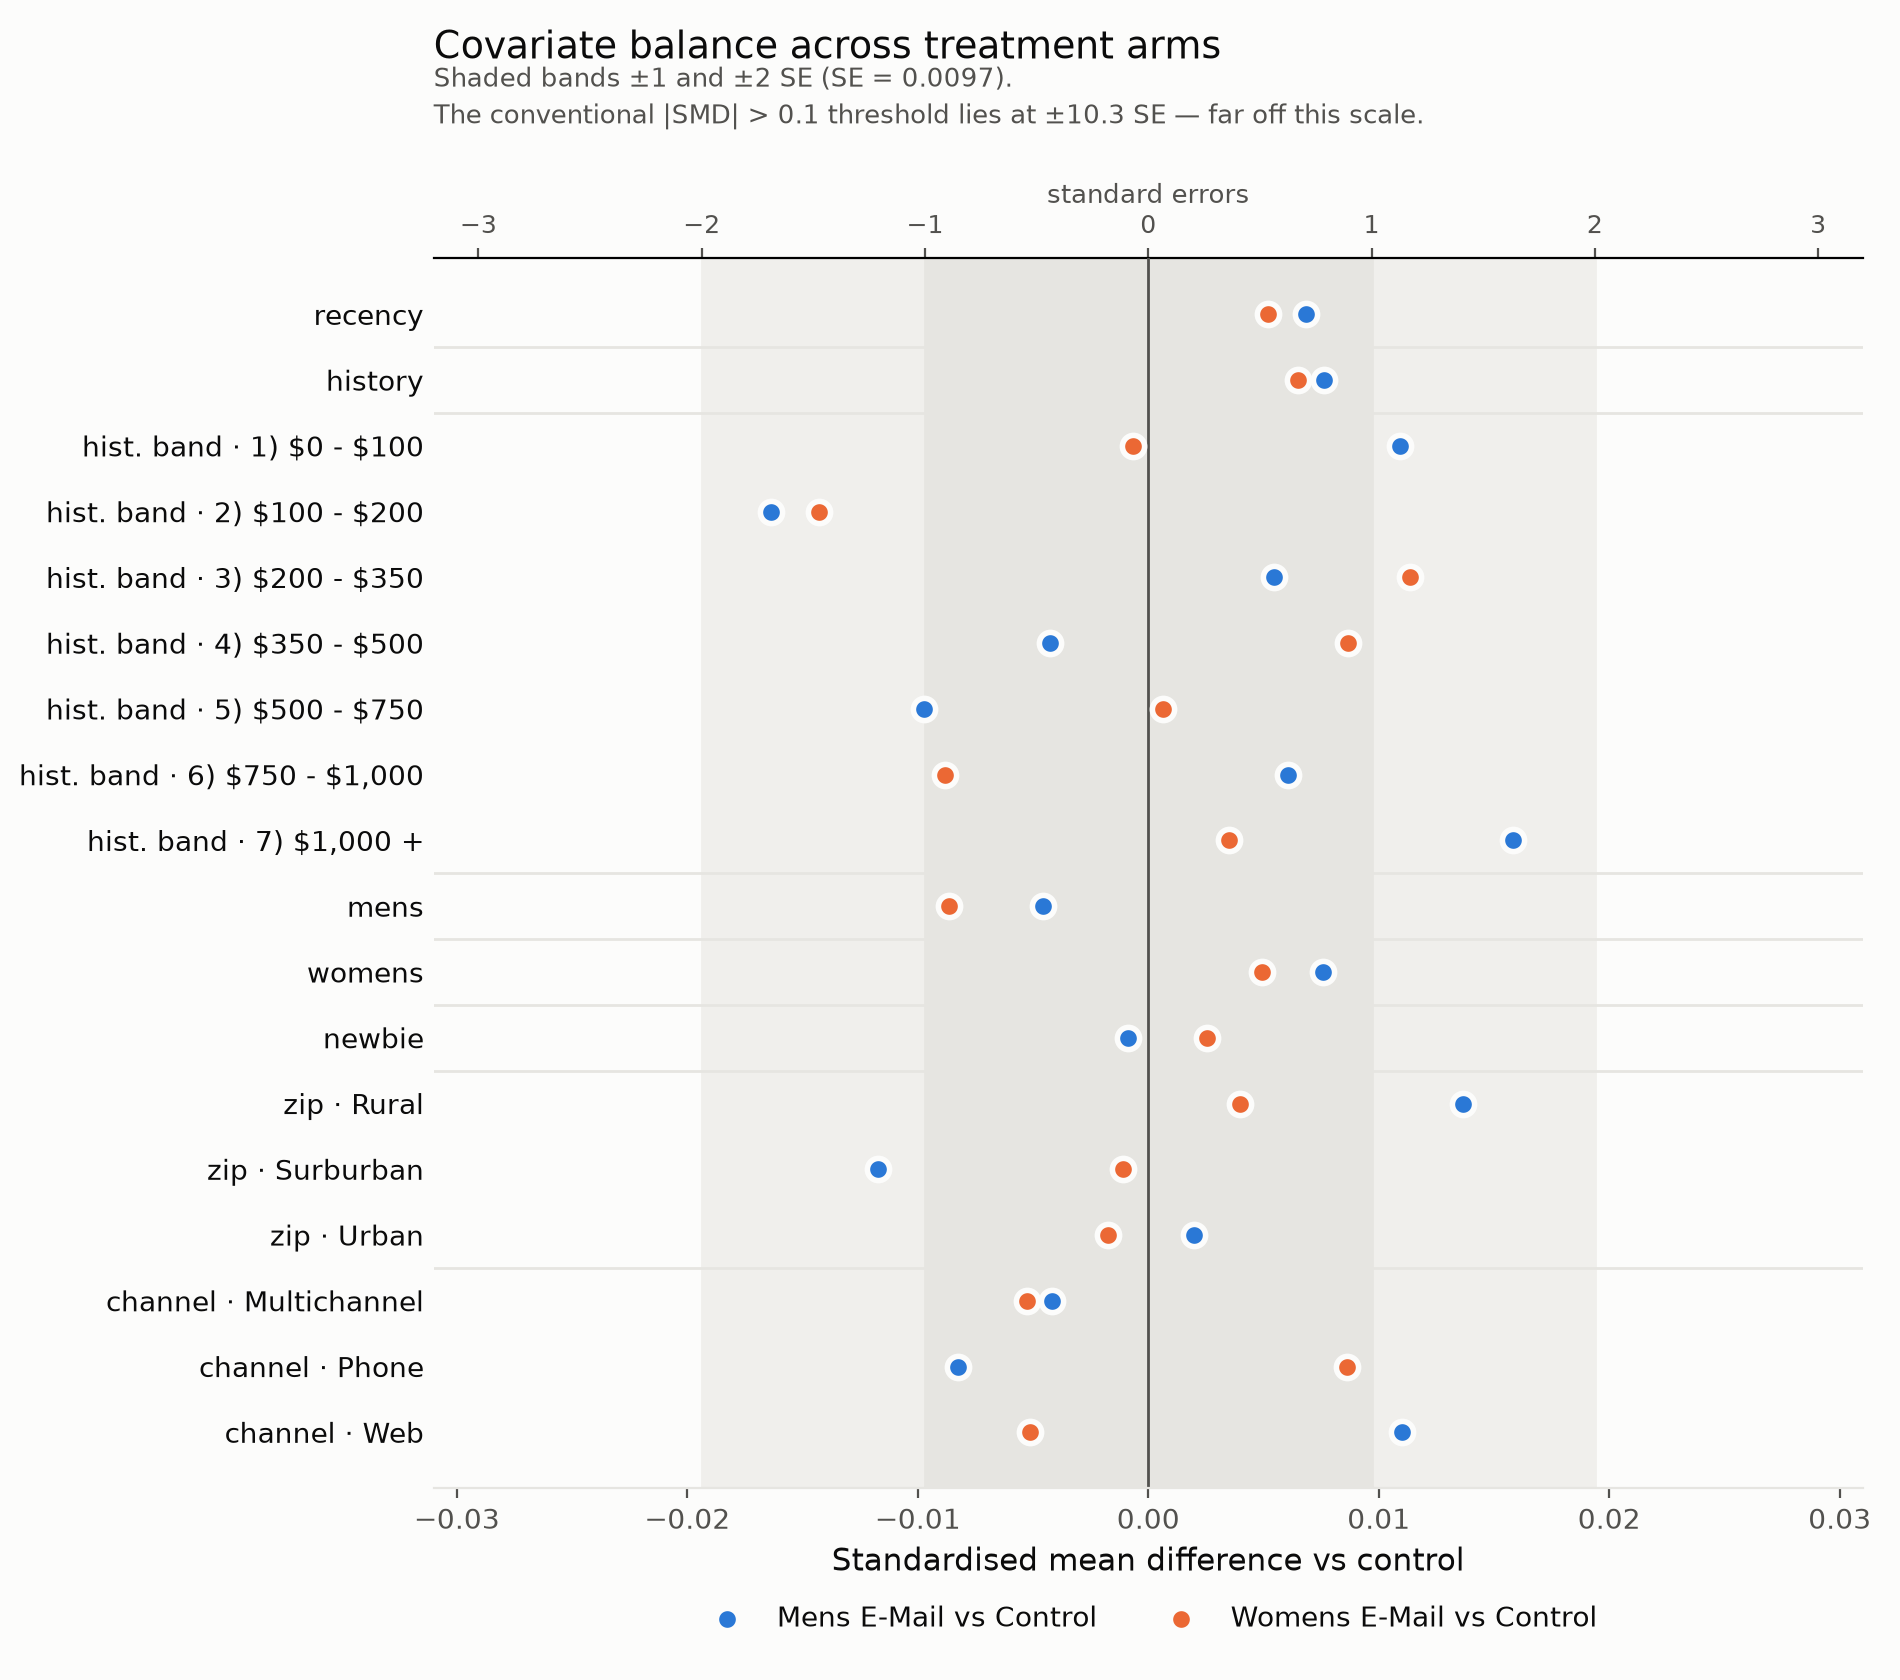

In [6]:
from IPython.display import Image
from src.plots import LIGHT, love_plot
from src.db import PROJECT_ROOT

love_plot(smd, cal["theoretical_se"], LIGHT, PROJECT_ROOT / "figures" / "covariate_balance.png")
Image(str(PROJECT_ROOT / "figures" / "covariate_balance.png"), width=900)

## Verdict

**Randomisation checks out.** No sample ratio mismatch (p = 0.90), and covariate
SMDs scatter at 0.84× the noise level randomisation predicts, with the largest
deviation at 1.69 SE.

Two caveats that belong with that verdict:

- **Balance p-values are not the evidence.** Under true randomisation the null of
  balance is *known* to be true, so a balance test is not testing a hypothesis —
  with enough rows, any trivial difference becomes "significant." The p-value
  column exists to demonstrate that point, not to support the conclusion.
- **A single imbalanced covariate would not have meant failure.** Across 36
  comparisons, roughly 1.8 nominally significant results are expected by chance.
  Treating one flagged row as proof of a broken randomiser is a misreading. Here
  the question is moot — there were zero — but the reasoning is what generalises.

Balance being confirmed is also what licenses the covariate adjustment
pre-registered in §5: the Lin estimator buys precision, and with arms this
similar it is not silently repairing a compositional difference.

**Still no treatment effect has been computed.** That happens in Phase 4.